# Mouse DESeq2 team walkthrough — All 20 (`SRP618841`)

This is the team-share version of the `mouse_new` DE notebook. It shows how the `SRP618841` differential-expression output was organized and highlights the main DRG-family results without requiring the full private working tree.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..').resolve()
DATA = ROOT / 'data' / 'differential_expression_all20'
TABLES = DATA / 'tables'
FAMILY = DATA / 'family_drg_novaseqx'
FIGS = FAMILY / 'figures'
FTABLES = FAMILY / 'tables'

## What comes from alignment

The DE inputs come from the STAR alignment stage: the reverse-stranded count matrix and the sample summary table were turned into the design/contrast package used by the DESeq2 run.


In [2]:
design = pd.read_csv(TABLES / 'mouse_de_design_table.tsv', sep='	')
family_manifest = pd.read_csv(TABLES / 'family_manifest.tsv', sep='	')
contrast_manifest = pd.read_csv(TABLES / 'contrast_manifest.tsv', sep='	')
display(design.head())
display(family_manifest)
display(contrast_manifest[['family_id', 'contrast_id', 'contrast_label', 'n_significant']])

,srr,sample_title,source_name,platform_family,source_class,geno_class,side_class,condition_family,family_id,gc_status,genotype,treatment,include_in_de,excluded_reason
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN


,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,design
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,~ side_class + geno_class + side_class:geno_class


,family_id,contrast_id,contrast_label,n_significant
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),891
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),2
2,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,7023
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,7541
4,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,14


## DRG family membership

For this candidate dataset, the DE run resolves to one family: `family_drg_novaseqx`.


In [3]:
sample_table = pd.read_csv(FTABLES / 'sample_table.tsv', sep='	')
filtering = pd.read_csv(FTABLES / 'filtering_summary.tsv', sep='	')
display(sample_table)
display(filtering)

,srr,sample_title,geno_class,side_class,platform_family,gc_status
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",cre,ipsi,NovaSeq X,WARN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
5,SRR35329982,"Replicate H62, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
6,SRR35329983,"Replicate H61, CRE genotype, Ipsilateral tissue",cre,ipsi,NovaSeq X,WARN
7,SRR35329984,"Replicate H62, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN
8,SRR35329985,"Replicate H64, CRE genotype, Contralateral tissue",cre,contra,NovaSeq X,WARN
9,SRR35329986,"Replicate H63, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN


,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,min_samples_count_ge_10
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,3


## Family diagnostics

These plots show whether the DRG family is structured well enough to interpret.


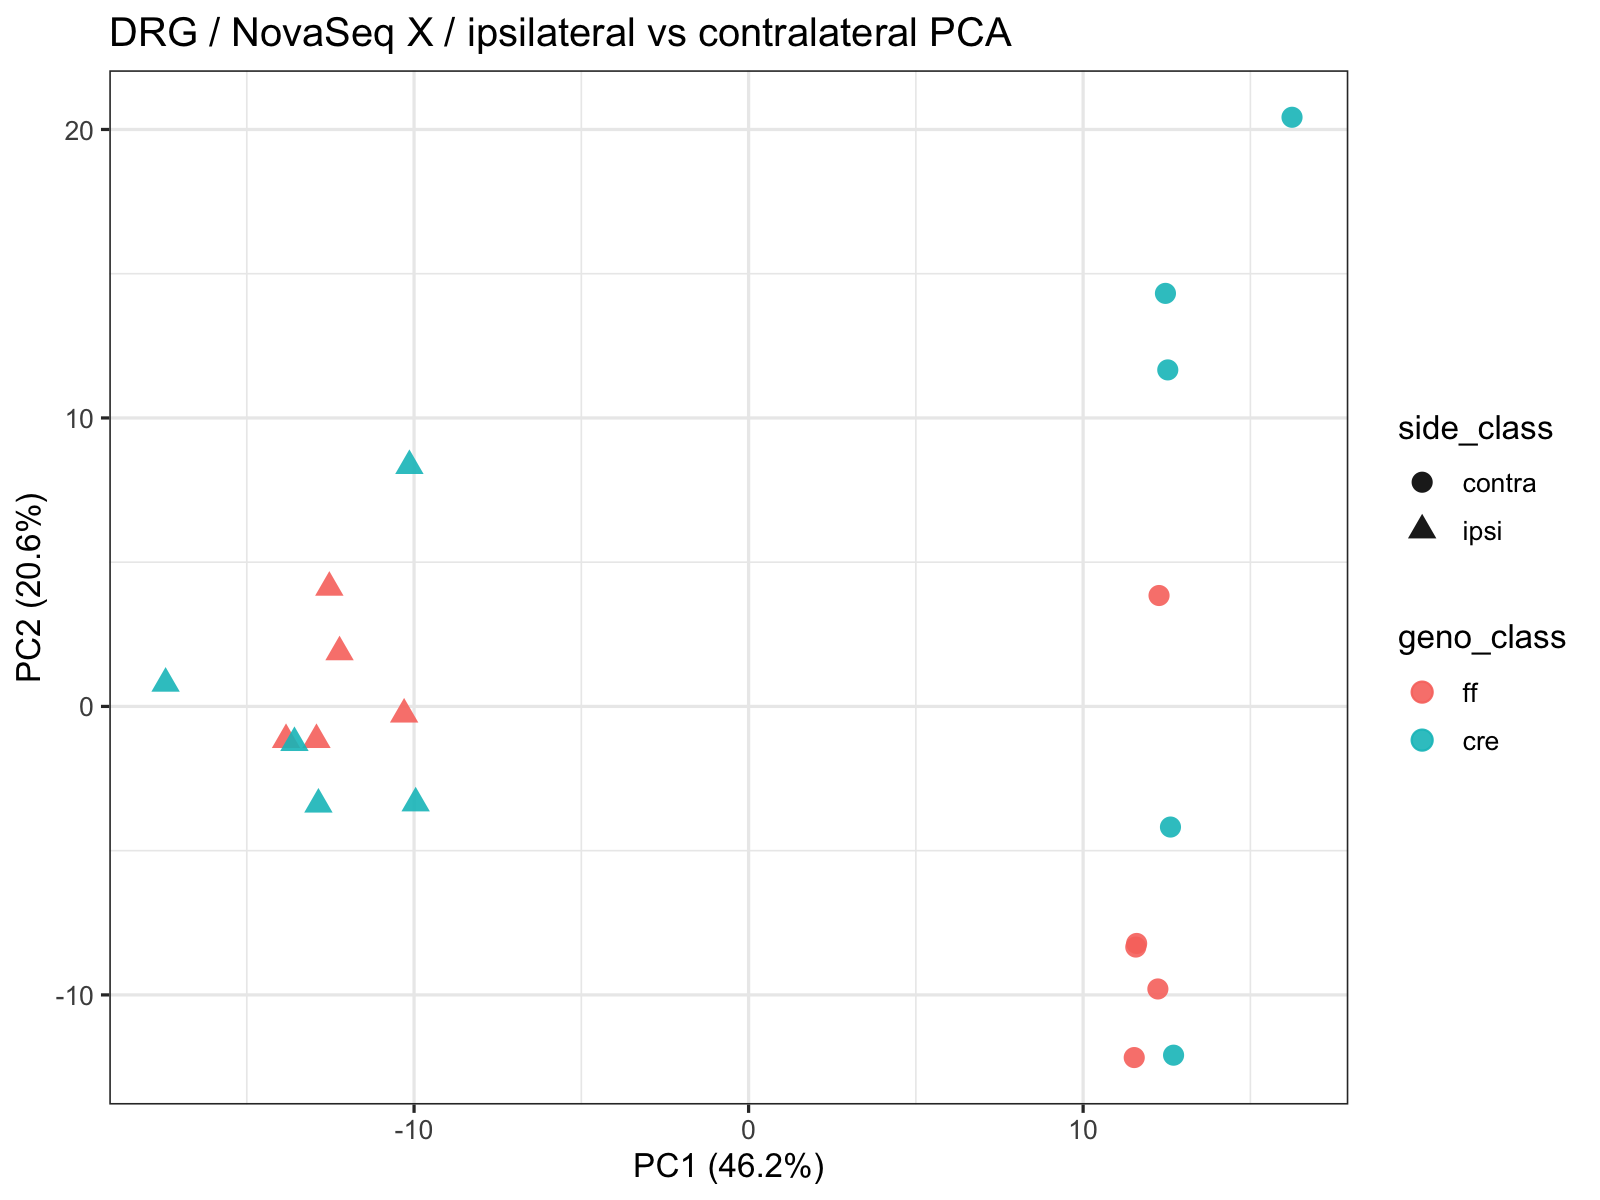

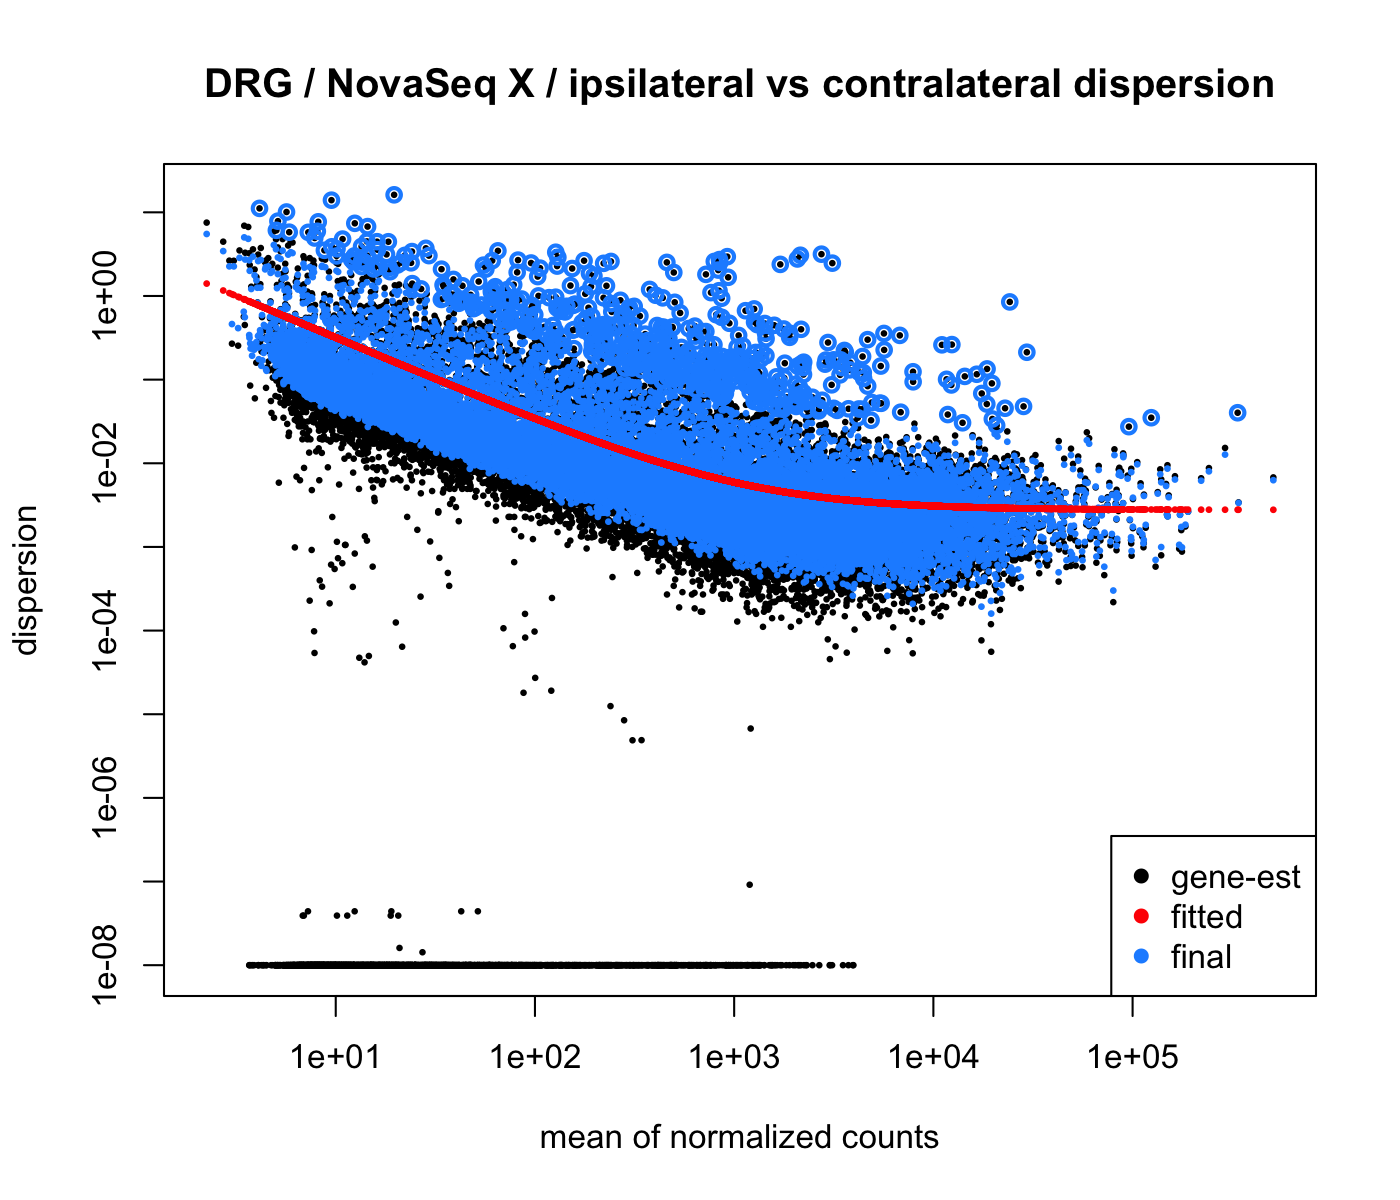

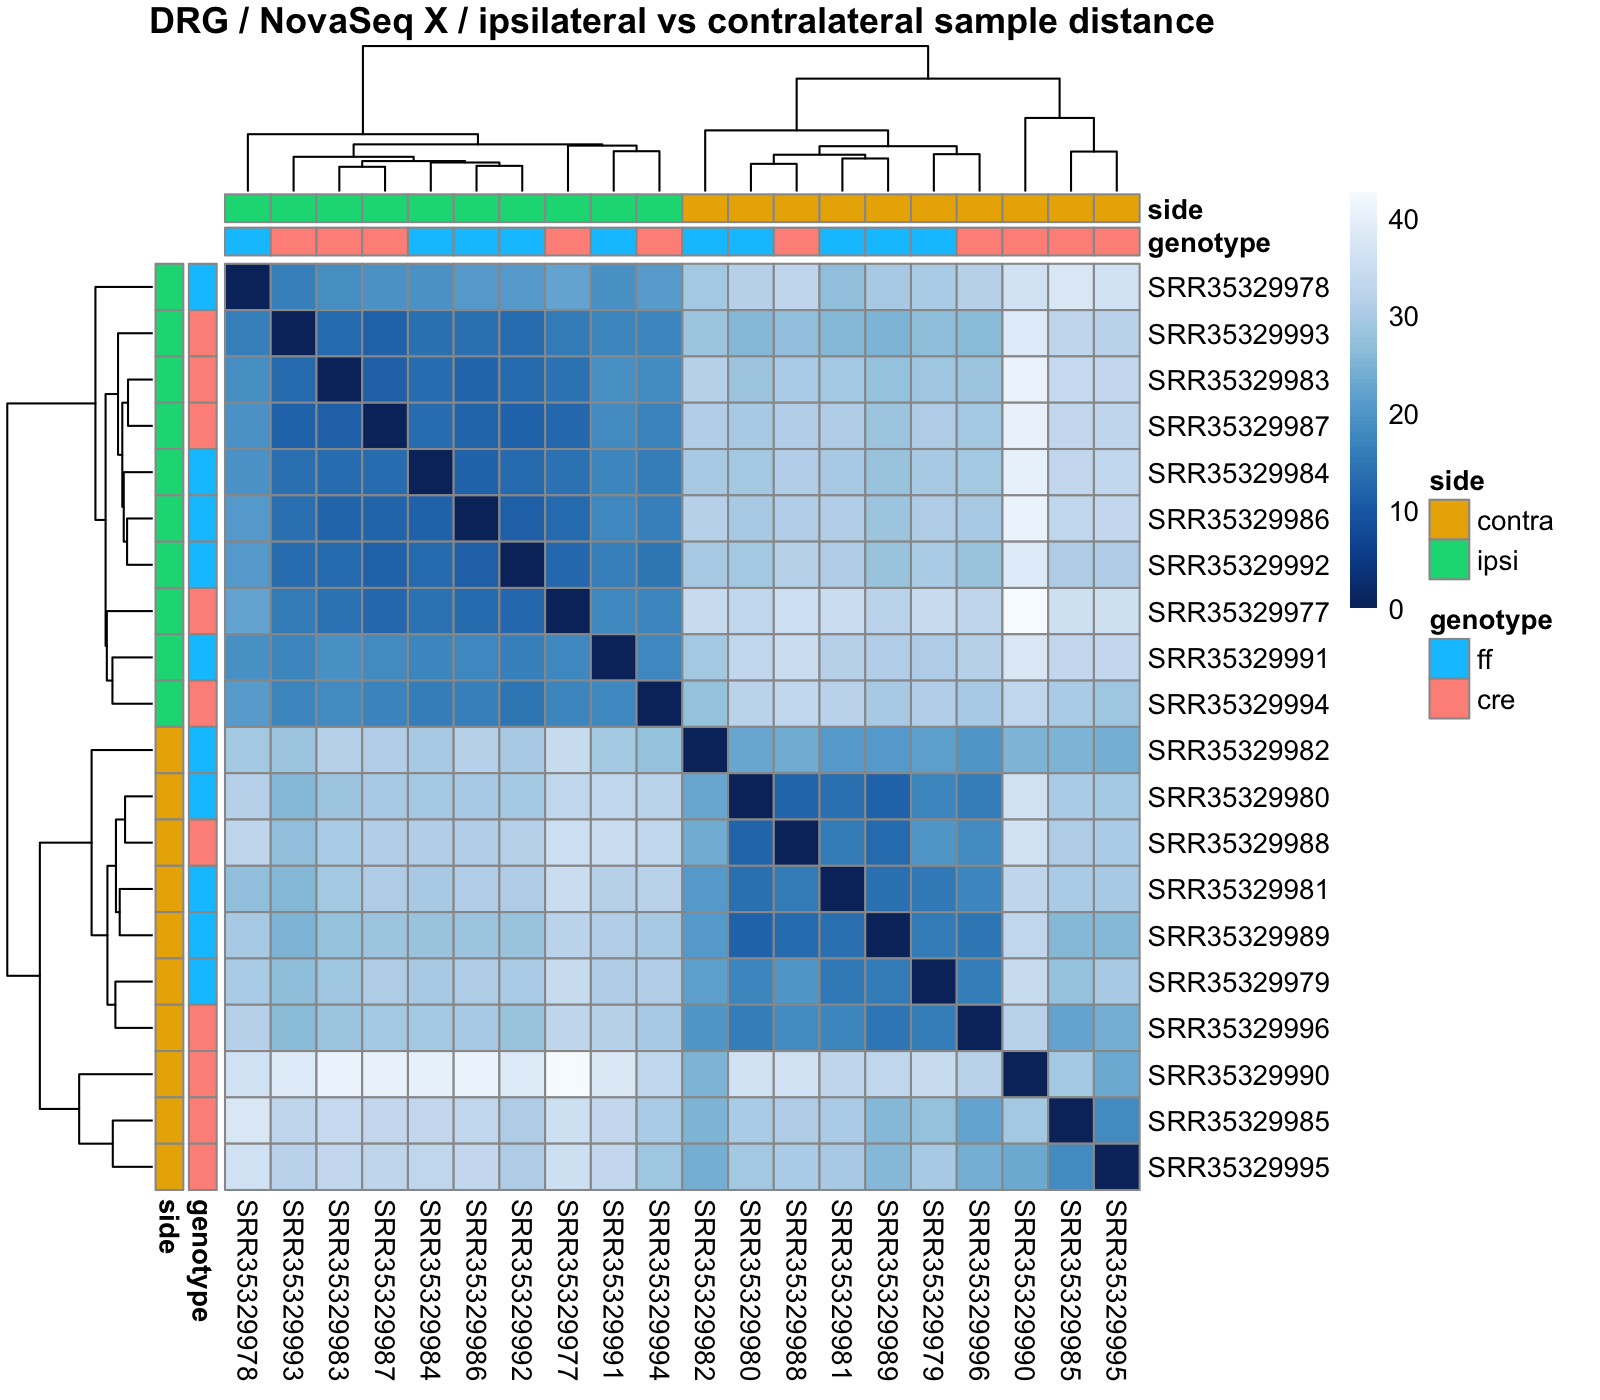

In [4]:
display(Image(filename=str(FIGS / 'pca.png'), width=900))
display(Image(filename=str(FIGS / 'dispersion.png'), width=900))
display(Image(filename=str(FIGS / 'sample_distance_heatmap.png'), width=900))

The main qualitative message is that side (`ipsi` vs `contra`) is the dominant global split in the PCA, while genotype looks more secondary.


## Main contrast previews

These are the easiest files to show when someone asks where the strongest gene-level differences appear.


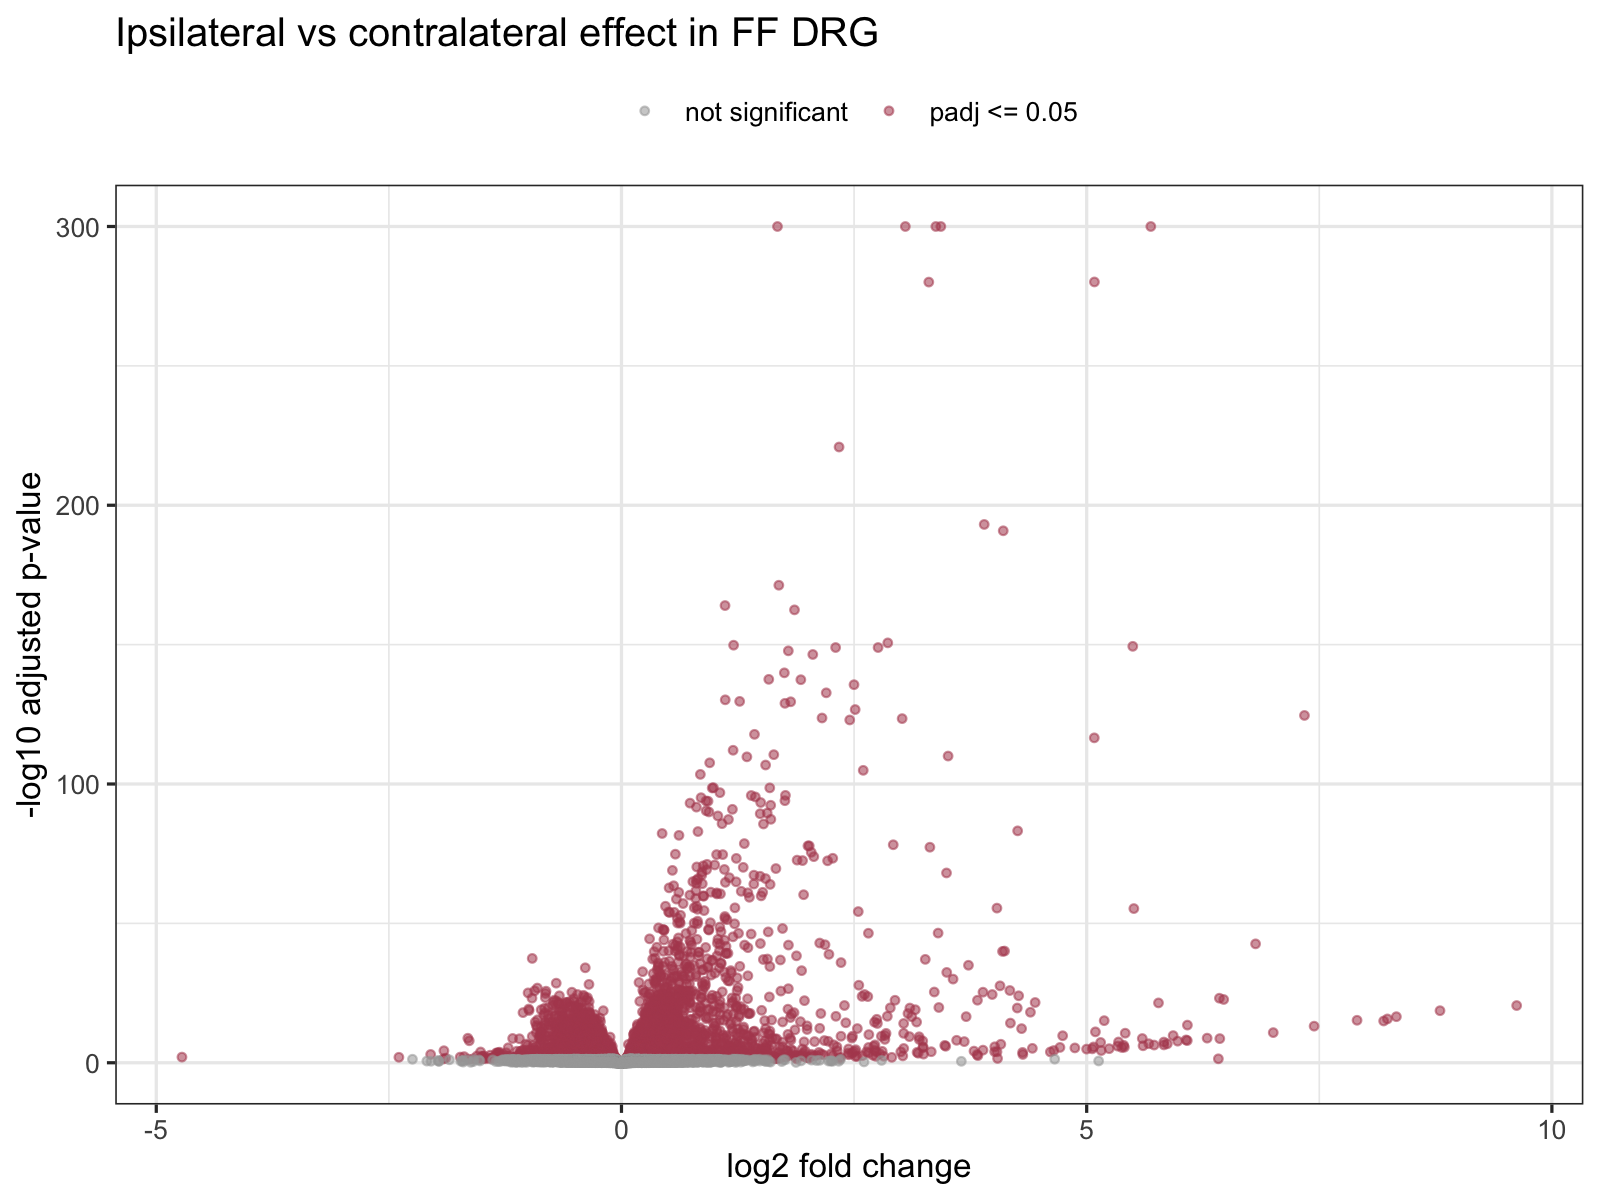

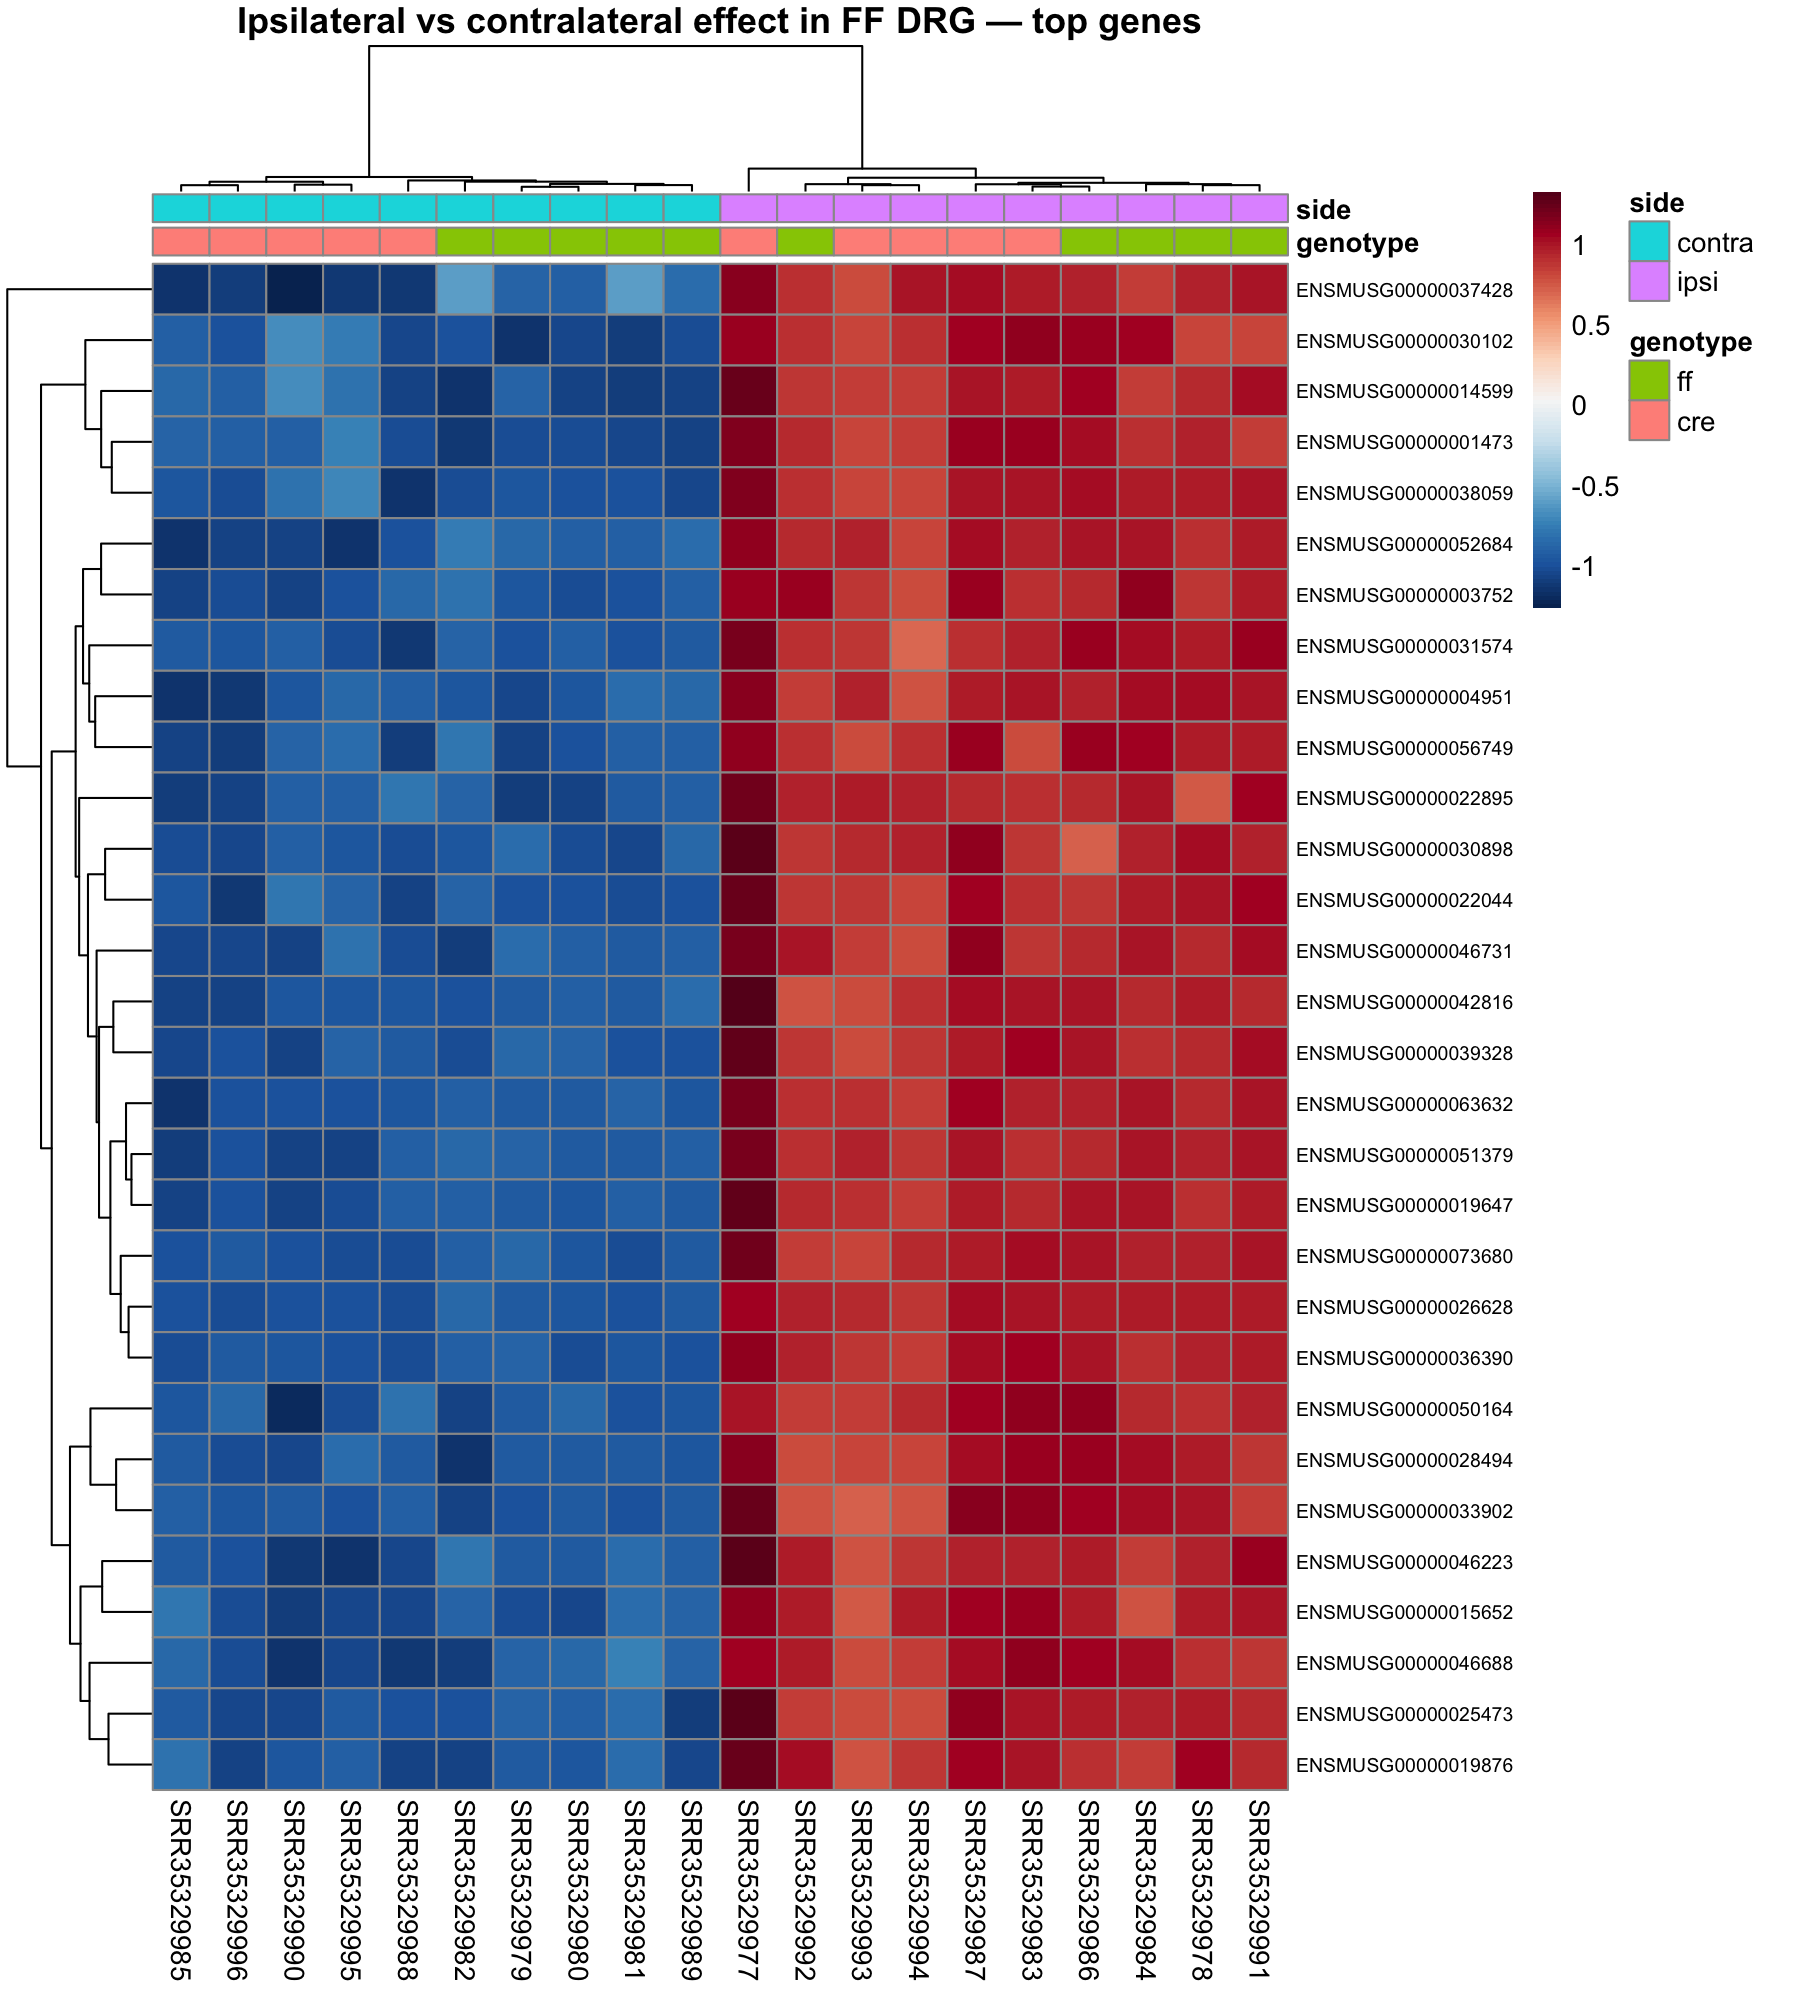

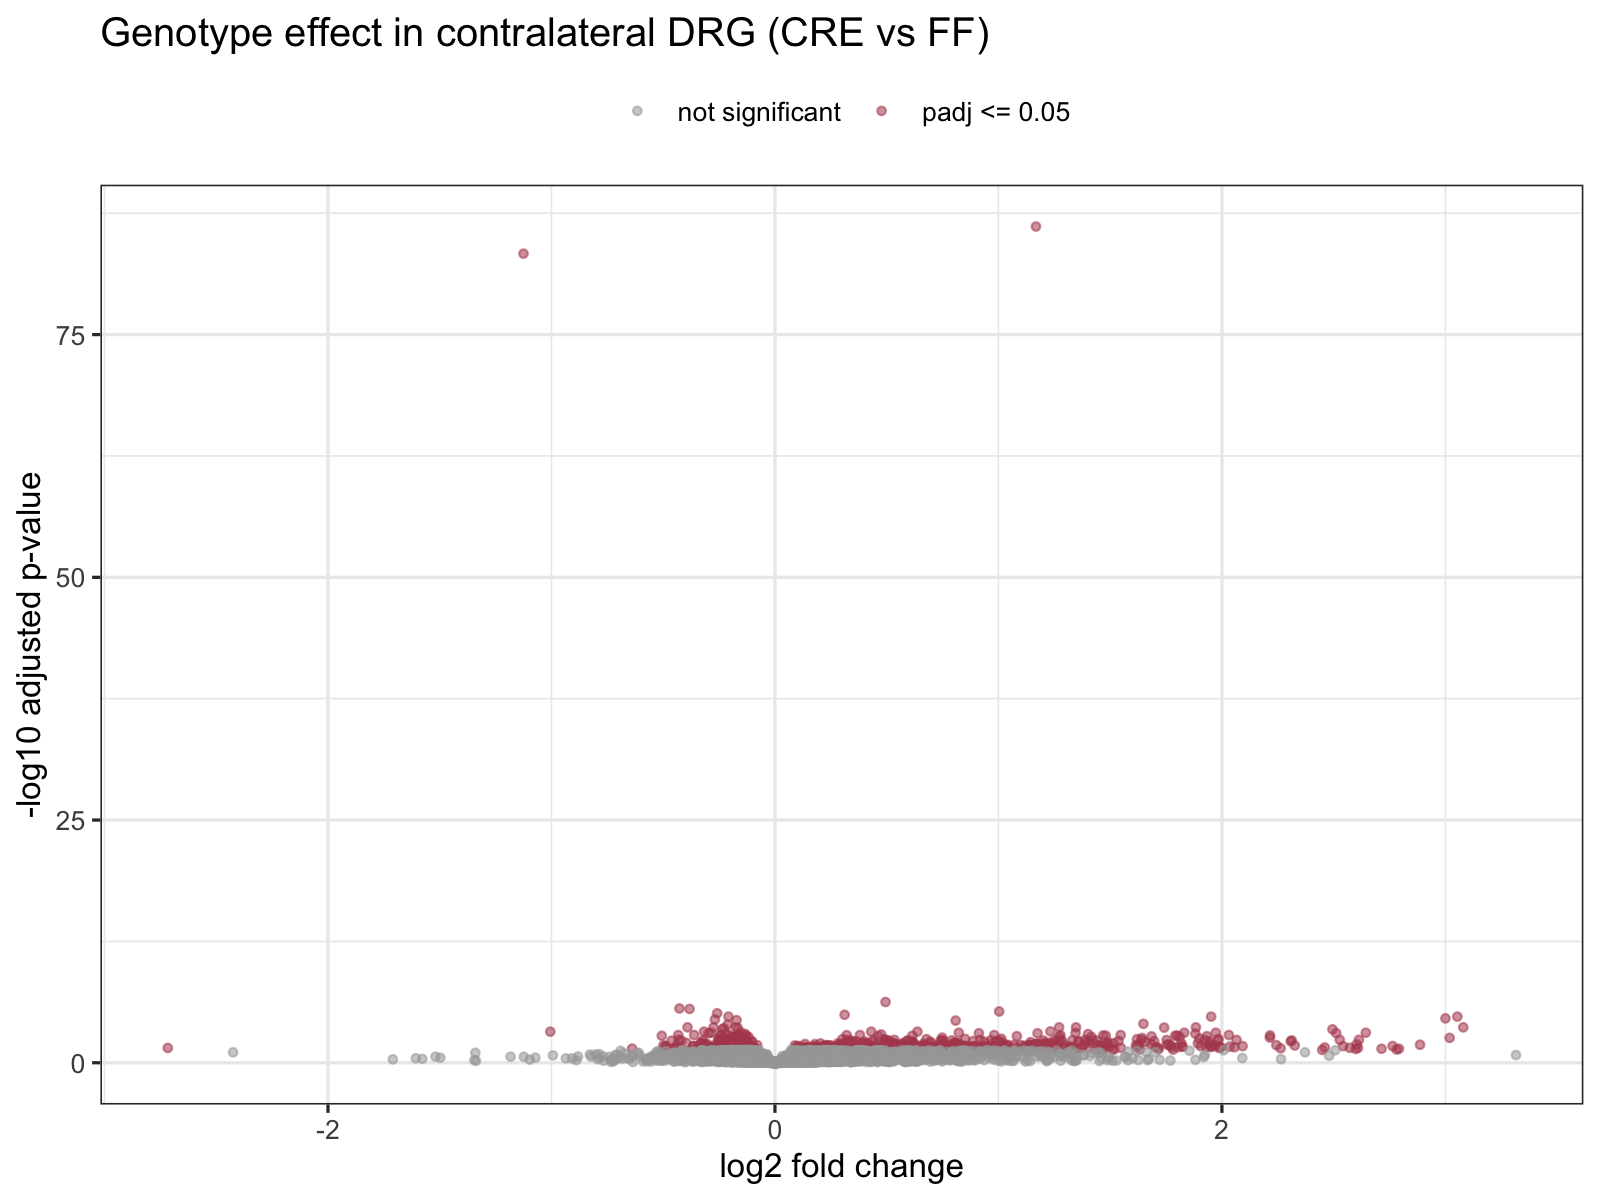

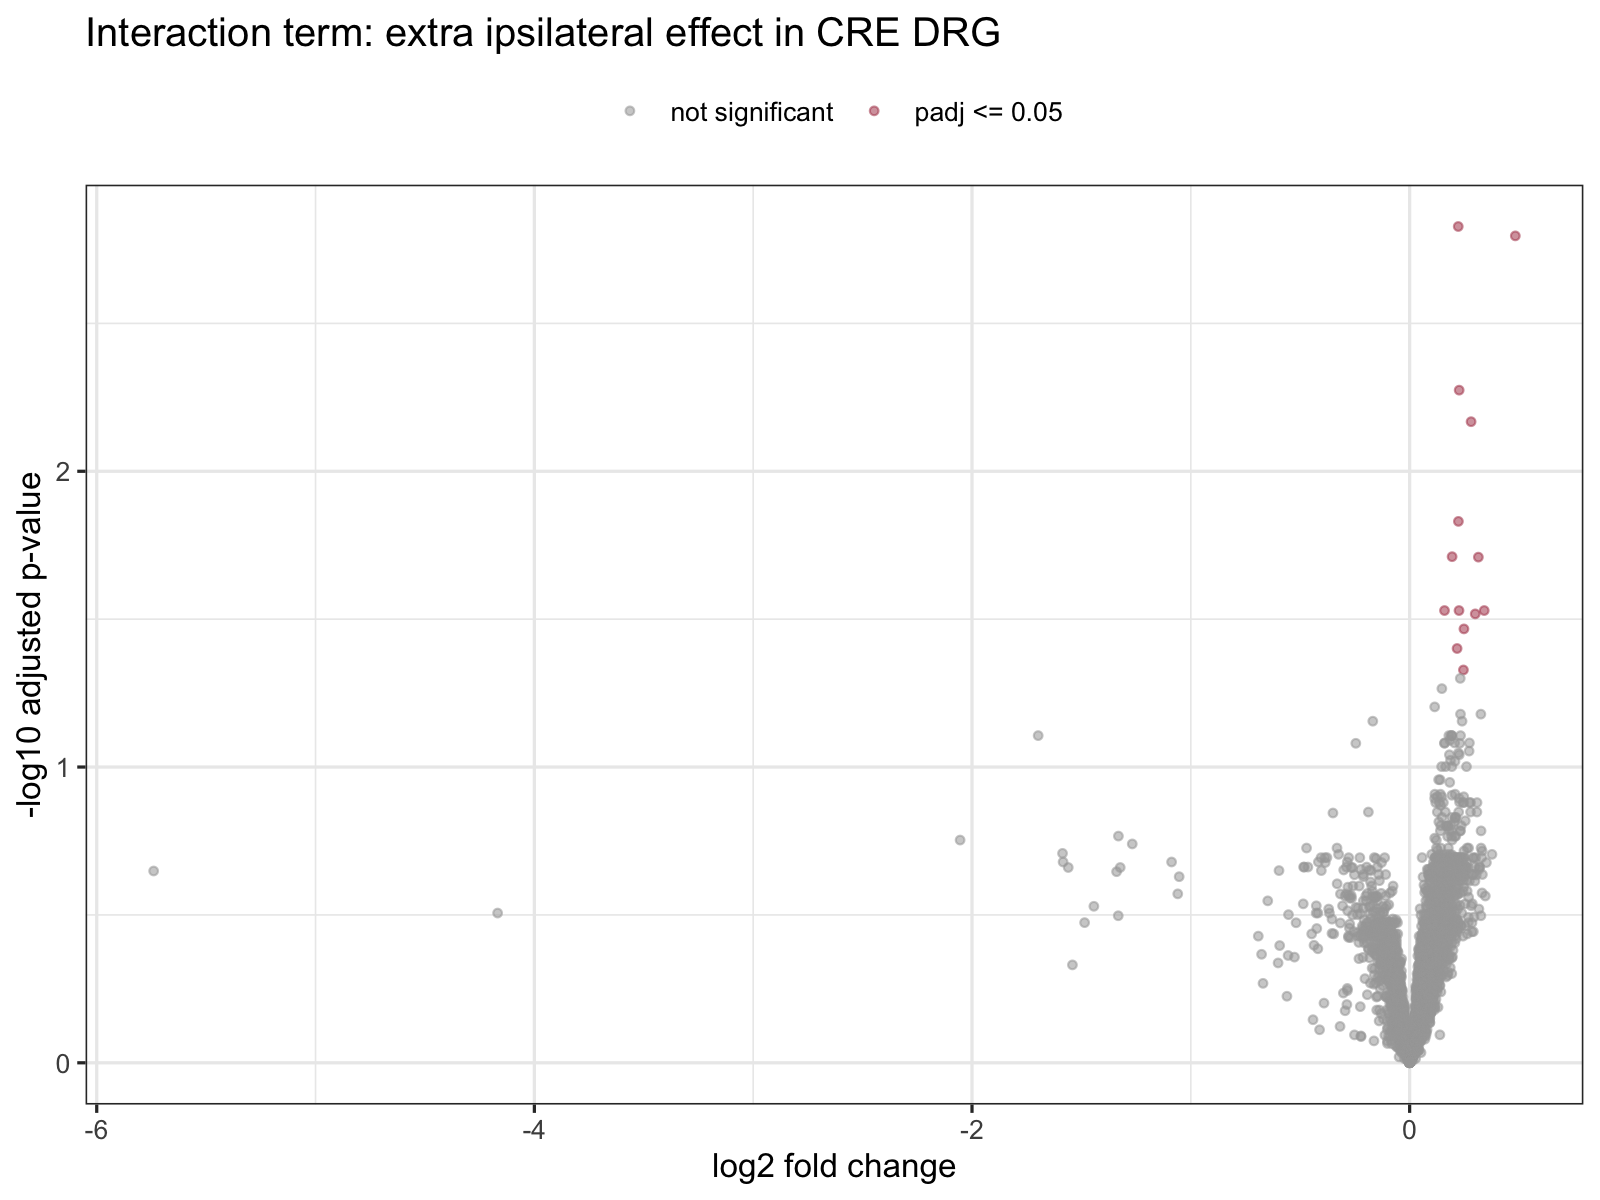

In [5]:
display(Image(filename=str(FTABLES / 'ipsi_vs_contra_in_ff_volcano.png'), width=900))
display(Image(filename=str(FTABLES / 'ipsi_vs_contra_in_ff_heatmap.png'), width=900))
display(Image(filename=str(FTABLES / 'geno_in_contra_volcano.png'), width=900))
display(Image(filename=str(FTABLES / 'interaction_volcano.png'), width=900))

In [6]:
display(pd.read_csv(FTABLES / 'ipsi_vs_contra_in_ff_top_genes.tsv', sep='	').head(20))
display(pd.read_csv(FTABLES / 'ipsi_vs_contra_in_cre_top_genes.tsv', sep='	').head(20))

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


## Main takeaways

- The `SRP618841` DE run completed for one balanced DRG family on `NovaSeq X`.
- The strongest visible structure is by side (`ipsi` vs `contra`).
- The shared output tree on `sequoia` is:
  - `/home/zebrafish/mouse/SRP618841_parallel/differential_expression_all20`
